# &laquo;Машинное обучение&raquo;, AI Masters

### Домашняя работа №7. Методы понижения размерности, кластеризация. Пакеты для интерактивной визуализации.

### Задача 1. Подбор параметров UMAP и оценка полученной визуализации (4 балла)

Для вас загружен датасет по данным секвенирования одиночных клеток. Датасет уже предобработан, в задаче нет необходимости вникать в специфику данных (кому интересно - [источник](https://doi.org/10.1101/2021.09.16.460628) датасета).

**Задача 1.1 (2 балла)** Предобработайте ваш датасет: найдите в нем ближайших соседей одним из быстрых способов, поддерживающих sparse-данные. После этого научитесь передавать таких соседей в UMAP (изучите, что принимает на вход параметр `precomputed_knn`). Сравните полученную визуализацию с запуском класса `umap.UMAP` на sparse матрице с исходными данными.
#### Шаг 1. Запуск umap на sparse матрице со стандартными параметрами
- код выполнился за 51 минуту umap.UMAP(n_neighbors=15, n_components=2,metric="euclidian", random_state=0)
- код выполнился за 3 минуты (без random_state)
- **Вывод**. Отрисован график: большинство точек разделились по кластерам в соответствии с метками cell_type, но есть наложение кластеров, а также точки прилипшие к чужому кластеру
#### Шаг 2. Подготовка индекса ближайших соседей
Индекс ближайших соседей построен с помощью pynndescent:
- metric='cosine' (на шаге 6 в umap задаю как cosine, так и eucledian. Видимо, это ошибка)
- n_neighbours = 50, чтобы передавать до 50 соседей в umap 
- индекс построился за 20 мин.
#### Шаг 3. Визуализация результатов umap с разным числом n_neighbours
- попробовал 10,20,30 и 50 соседей. fit_transform отработал за 40-50 секунд, random_state = 0.
- отрисовал в matplotlib 4 графика для 10,20,30 и 50 соседей
- **Вывод**: разницы со стандартными настройками не обнаружено, но precomputed_knn ускорил umap в 50 раз (с 50 минут до 50 секунд)
- с увеличением числа соседей уменьшается число шумовых точек
- в качестве оптимального параметра выбрал **30 соседей**
#### Шаг 4. Визуализация результатов umap с разным числом min_dist
- попробовал 0, 0.05, 0.1 и 0.2.
- 0..0.1 почти не отличимы. 0.2 - кластеры стали более расплющенными и близкими друг к другу
- в качестве оптимального оставил **min_dist = 0.05**
#### Шаг 5. Umap с оптимальными "на глаз" параметрами, визуализация в plotly
- для каждого cell_type наблюдается 1, максимум, 2 кластера и разбросанные по пространству шумовые точки

**Задача 1.2. (2 балла)** Подберите параметры UMAP таким образом, чтобы по данным получались наилучшие кластеры из атрибута `cell_type` (см. метаданные). Придумайте <u>количественный</u> способ оценки получаемого пространства (известная разметка на кластеры в этом пространстве должна быть хорошей). Попробуйте различные параметры UMAP и добейтесь улучшения вашей функции качества относительно запуска с параметрами по умолчанию.
#### Шаг 6. Запуск umap с перебором параметров по сетке n_neigbours in [10,15,20,30], min_dist in [0, 0.05, 0.1, 0.2], metric in ['cosine', 'eucledian']
- понижение размерности
- кластеризация kmeans на k-кластеров, где k - число уникальных cell_type
- расчет adusted rand index (ARI) и normalized mutual information (NMI)
- вывод результатов сравнения в датафрейм
- удалось найти 4 конфигурации параметров, дающих лучшую метрику, чем стандартная конфигурация (nn = 15, min_dist = 0.1, metric = 'eculedian')

|   n_neighbors |   min_dist | metric    |      ARI |      NMI |   ARI + NMI |
|--------------:|-----------:|:----------|---------:|---------:|------------:|
|            30 |       0    | euclidean | 0.839385 | 0.882992 |     1.72238 |
|            30 |       0.1  | euclidean | 0.838143 | 0.879216 |     1.71736 |
|            15 |       0.3  | cosine    | 0.825043 | 0.875433 |     1.70048 |
|            10 |       0.1  | cosine    | 0.824032 | 0.875317 |     1.69935 |
|            15 |       0.1  | euclidean | 0.823282 | 0.87026  |     1.69354 |
|            15 |       0    | cosine    | 0.819097 | 0.872947 |     1.69204 |
|            10 |       0    | euclidean | 0.818171 | 0.866209 |     1.68438 |
|             5 |       0.05 | euclidean | 0.807002 | 0.843344 |     1.65035 |
|            15 |       0    | euclidean | 0.803255 | 0.861486 |     1.66474 |
|             5 |       0.1  | euclidean | 0.790586 | 0.850059 |     1.64065 |

Бонусные баллы будут ставиться за:
* Хорошую работу, оформление выводов.
* Понятную визуализацию, сравнение, интерактивные графики (если они уместны).
* Учет в получаемой 2D-структуре дополнительной информации из метаданных.
* Все остальные правила из семинара 1 тоже действуют :)

<font color='red'>**Обязательно**</font>: в конце задания продемонстрируйте полученный график / графики и сравните с дефолтными настройками! Если вы делали дополнительную работу, также кратко опишите, что было сделано и продемонстрируйте, что это работает! При проверке мы не сможем проверять ваш код на предмет наличия скрытого (или не очень скрытого) функционала, поэтому **вы не получите доп. баллы, если не покажете, как работает сделанная вами фишка**.

#### Шаг 0. Импорт библиотек, загрузка данных

In [ ]:
import numpy as np
import scipy as sp
import pandas as pd
import umap
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
pio.renderers.default = 'vscode'
print("Plotly renderer set to 'vscode'")


In [28]:
!wget https://data.bioml.ru/htdocs/courses/bioml/classic_ml/unsupervised/dim_reduction/data/singlecell/expression_data.npz -O expression_data.npz 2> /dev/null
!wget https://data.bioml.ru/htdocs/courses/bioml/classic_ml/unsupervised/dim_reduction/data/singlecell/metadata_row.parquet -O metadata_row.parquet 2> /dev/null
!wget https://data.bioml.ru/htdocs/courses/bioml/classic_ml/unsupervised/dim_reduction/data/singlecell/metadata_col.parquet -O metadata_col.parquet 2> /dev/null

In [3]:
data = sp.sparse.load_npz('expression_data.npz')
meta_row = pd.read_parquet('metadata_row.parquet')
meta_col = pd.read_parquet('metadata_col.parquet')
data.shape, meta_row.shape, meta_col.shape

((50753, 1000), (50753, 4), (1000, 2))

##### Функции

In [ ]:
# Определим конфигурацию UMAP и функцию стабильного хеширования для сохранения результатов на диск
from dataclasses import dataclass, asdict
from typing import Optional, Tuple
from pathlib import Path
import json
import hashlib
import joblib

@dataclass(frozen=True)
class UMAPConfig:
    # Ставим параметры по умолчанию
    n_neighbors: int = 15
    min_dist: float = 0.1
    n_components: int = 2
    metric: str = "euclidean"
    # логический флаг
    use_precomputed_knn: bool = False

def stable_hash(cfg: UMAPConfig) -> str:
    s = json.dumps(asdict(cfg), sort_keys=True)
    return hashlib.md5(s.encode()).hexdigest()

def get_umap_embedding(
    X: np.ndarray | sp.sparse.spmatrix,
    cfg: UMAPConfig,
    force: bool = False,
    precomputed_knn: Optional[Tuple[np.ndarray, np.ndarray]] = None
) -> np.ndarray:
    """
    Запускает UMAP с конфигом cfg.
    Сначала пытается загрузить embedding с диска, если force=False.
    """
    
    # Настройка параметров с учетом precomputed_knn
    knn_passed = precomputed_knn is not None
    if knn_passed != cfg.use_precomputed_knn:
        ValueError("Конфликт параметров: precomputed_knn передан, но use_precomputed_knn в конфиге не установлен, или наоборот.")
    umap_kwargs = asdict(cfg)
    umap_kwargs.pop("use_precomputed_knn", None)
    if cfg.use_precomputed_knn:
        umap_kwargs["precomputed_knn"] = precomputed_knn
    
    # Директория для кеша
    cache_dir = Path('embeddings')
    cache_dir.mkdir(parents=True, exist_ok=True)

    # Пути к файлам
    h = stable_hash(cfg)
    emb_path = cache_dir / f"umap_{h}.joblib"
    cfg_path = cache_dir / f"umap_{h}.json"

    # 1. Попытка загрузки
    if emb_path.exists() and not force:
        embedding = joblib.load(emb_path)
        return embedding

    # 2. Пересчёт
    model = umap.UMAP(**umap_kwargs)
    embedding = model.fit_transform(X)

    # 3. Сохранение
    joblib.dump(embedding, emb_path)
    cfg_path.write_text(json.dumps(asdict(cfg), indent=2, sort_keys=True))

    return embedding

In [9]:
def cfg_to_str(cfg: UMAPConfig) -> str:
    return ", ".join(f"{k}={v}" for k, v in asdict(cfg).items())

def scatter_plot(
    cfg: UMAPConfig,
    title: str = "UMAP embedding",
):
    """
    Рисует scatter plot UMAP / t-SNE / любого 2D embedding в Plotly.

    Parameters
    ----------
    embedding : np.ndarray, shape (n_samples, 2)
    """
    global embeddings, meta_row
    x_name = "Component 1"
    y_name= "Component 2"
    point_size = 6
    opacity = 0.85
    width = 1000
    height = 700

    embedding = embeddings[cfg]
    if embedding.shape[1] != 2:
        raise ValueError("embedding должен быть размерности (n_samples, 2)")

    df = pd.DataFrame({
        x_name: embedding[:, 0],
        y_name: embedding[:, 1],
        'label': meta_row['cell_type']
    })
    
    title = (
      title + "<br>"
      f"<sup>{cfg_to_str(cfg)}</sup>"
    )

    fig = px.scatter(
        df,
        x=x_name,
        y=y_name,
        color='label',
        title=title,
        opacity=opacity,
    )

    fig.update_traces(
        marker=dict(size=point_size),
        selector=dict(mode="markers")
    )

    fig.update_layout(
        width=width,
        height=height,
        legend_title_text='cell_type',
        legend=dict(
            itemsizing="constant",
            borderwidth=0,
        ),
        template="plotly_white",
    )

    fig.update_xaxes(title=x_name)
    fig.update_yaxes(title=y_name)

    return fig


#### Шаг 1. Запуск umap на sparse матрице со стандартными параметрами

In [ ]:
cfg_std = UMAPConfig()
embeddings[cfg_std] = get_umap_embedding(data, cfg_std)

In [11]:
scatter_plot(cfg_std, title="UMAP embedding (standard config)")

#### Шаг 2. Подготовка индекса ближайших соседей

In [ ]:
import pynndescent

index = pynndescent.NNDescent(
    data,
    metric='cosine',
    n_neighbors=50 
)

index.prepare()

knn_indices, knn_dists = index.neighbor_graph

np.savez(
    "umap_knn_50.npz",
    indices=knn_indices,
    dists=knn_dists
)

In [13]:
knn = np.load("umap_knn_50.npz")
knn_indices = knn["indices"]
knn_dists = knn["dists"]

 #### Шаг 3. Визуализация результатов umap с разным числом n_neighbours

In [19]:
import time

embeddings = {}
 
for n_neighbors in (10, 20, 30, 50):
    cfg = UMAPConfig(
        n_neighbors=n_neighbors,
        n_components=2,
        metric="cosine"
    )

    print(f"Running UMAP with {cfg}")
    start = time.perf_counter()

    embeddings[cfg] = get_umap_embedding(cfg=cfg, X=data, precomputed_knn=(knn_indices, knn_dists))

    elapsed = time.perf_counter() - start
    minutes = int(elapsed // 60)
    seconds = elapsed % 60
    print(f"Neighbours {cfg.n_neighbors}: {minutes} min {seconds:.1f} s\n")


Running UMAP with UMAPConfig(n_neighbors=10, min_dist=0.1, n_components=2, metric='cosine', use_precomputed_knn=False)
Neighbours 10: 0 min 0.0 s

Running UMAP with UMAPConfig(n_neighbors=20, min_dist=0.1, n_components=2, metric='cosine', use_precomputed_knn=False)
Neighbours 20: 0 min 0.0 s

Running UMAP with UMAPConfig(n_neighbors=30, min_dist=0.1, n_components=2, metric='cosine', use_precomputed_knn=False)
Neighbours 30: 0 min 0.0 s

Running UMAP with UMAPConfig(n_neighbors=50, min_dist=0.1, n_components=2, metric='cosine', use_precomputed_knn=False)
Neighbours 50: 0 min 0.0 s



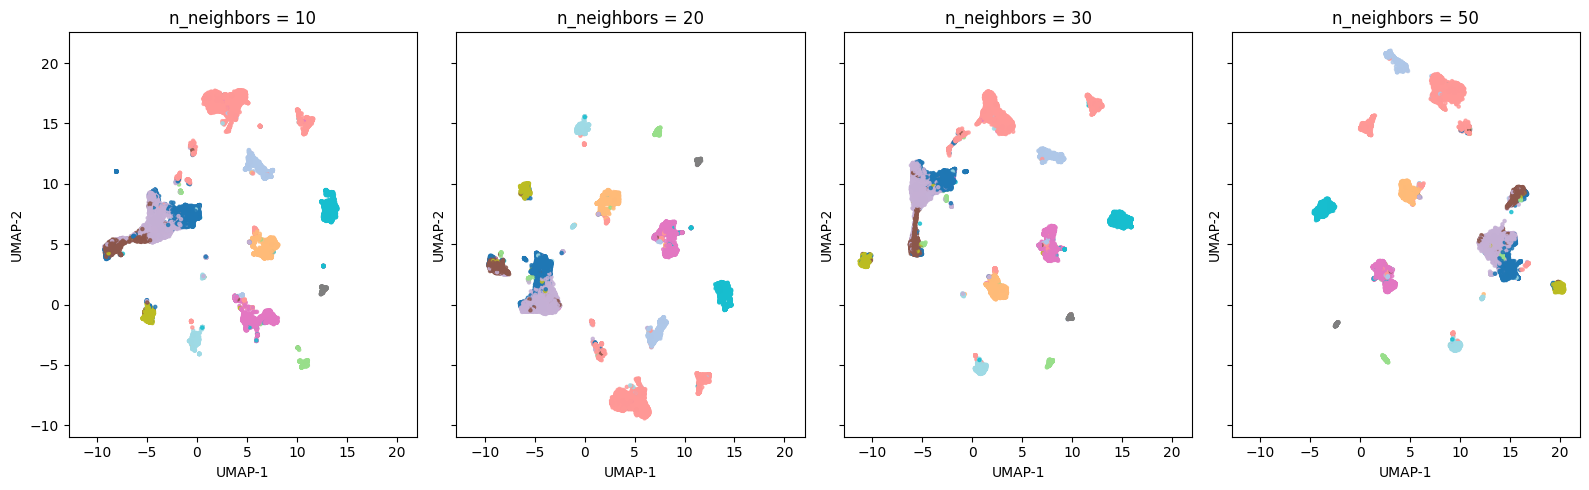

In [20]:
labels = meta_row["cell_type"].astype("category").cat.codes.values

fig, axes = plt.subplots(
    1,
    len(embeddings),
    figsize=(4 * len(embeddings), 5),
    sharex=True,
    sharey=True,
)

for ax, (cfg, emb) in zip(axes, embeddings.items()):
    ax.scatter(
        emb[:, 0],
        emb[:, 1],
        c=labels,
        s=5,
        cmap="tab20",
        alpha=0.8,
    )
    ax.set_title(f"n_neighbors = {cfg.n_neighbors}")
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")

plt.tight_layout()
plt.show()


#### Шаг 4. Визуализация результатов umap с разным числом min_dist

In [27]:
import time

# Фиксируем число соседей
N_NEIGHBORS = 30

# Значения min_dist для перебора
MIN_DISTS = (0.0, 0.05, 0.1, 0.2)

embeddings = {}
 
for min_dist in MIN_DISTS:
    cfg = UMAPConfig(
        n_neighbors=N_NEIGHBORS,
        min_dist=min_dist,
        n_components=2,
        metric="cosine",
        use_precomputed_knn=True
    )

    print(f"Running UMAP with {cfg}")
    start = time.perf_counter()

    embeddings[cfg] = get_umap_embedding(cfg=cfg, X=data, precomputed_knn=(knn_indices, knn_dists))

    elapsed = time.perf_counter() - start
    minutes = int(elapsed // 60)
    seconds = elapsed % 60
    print(f"Neighbours {cfg.n_neighbors}: {minutes} min {seconds:.1f} s\n")


Running UMAP with UMAPConfig(n_neighbors=30, min_dist=0.0, n_components=2, metric='cosine', use_precomputed_knn=True)
Neighbours 30: 0 min 11.9 s

Running UMAP with UMAPConfig(n_neighbors=30, min_dist=0.05, n_components=2, metric='cosine', use_precomputed_knn=True)
Neighbours 30: 0 min 12.2 s

Running UMAP with UMAPConfig(n_neighbors=30, min_dist=0.1, n_components=2, metric='cosine', use_precomputed_knn=True)
Neighbours 30: 0 min 0.0 s

Running UMAP with UMAPConfig(n_neighbors=30, min_dist=0.2, n_components=2, metric='cosine', use_precomputed_knn=True)
Neighbours 30: 0 min 13.7 s



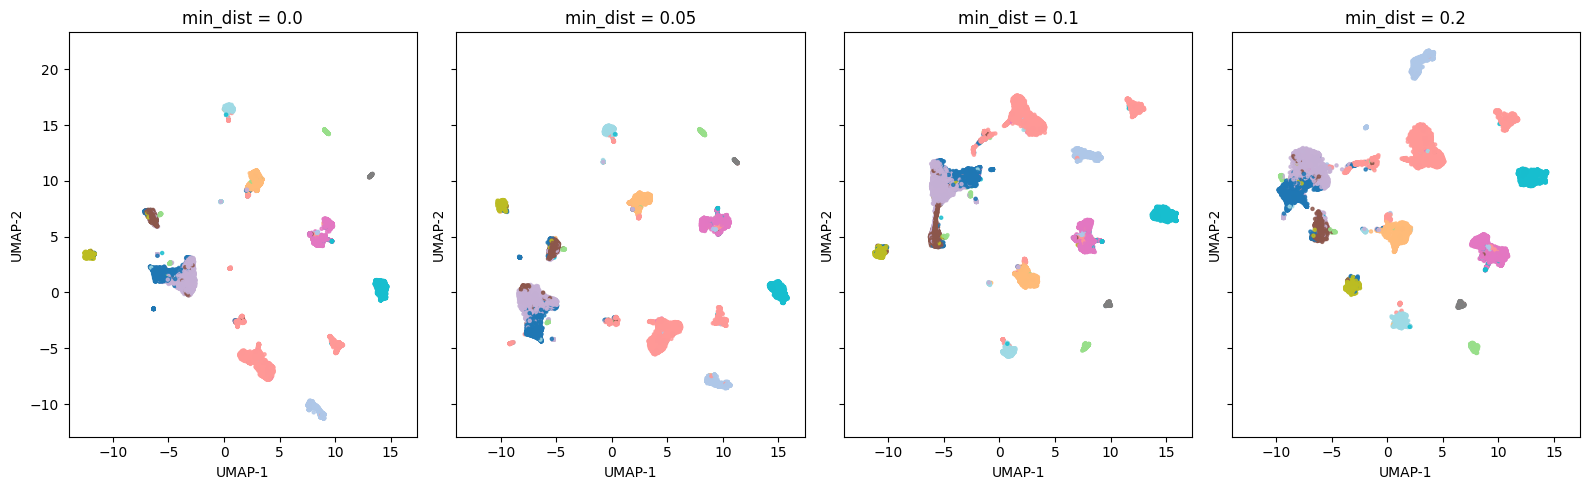

In [28]:
labels = meta_row["cell_type"].astype("category").cat.codes.values

fig, axes = plt.subplots(
    1,
    len(embeddings),
    figsize=(4 * len(embeddings), 5),
    sharex=True,
    sharey=True,
)

for ax, (cfg, emb) in zip(axes, embeddings.items()):
    ax.scatter(
        emb[:, 0],
        emb[:, 1],
        c=labels,
        s=5,
        cmap="tab20",
        alpha=0.8,
    )
    ax.set_title(f"min_dist = {cfg.min_dist}")
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")

plt.tight_layout()
plt.show()


#### Шаг 5. Umap с оптимальными "на глаз" параметрами, визуализация в plotly в 2D

In [ ]:
cfg = UMAPConfig(n_neighbors=30, min_dist=0.05, n_components=2, metric="cosine", use_precomputed_knn=True)
embeddings[cfg] = get_umap_embedding(cfg=cfg, X=data, precomputed_knn=(knn_indices, knn_dists))
scatter_plot(cfg, title="UMAP visually optimal embedding")

![image.png](images/img_001.png)

#### Шаг 6. Запуск umap с перебором параметров по сетке

In [34]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import normalized_mutual_info_score

results = []
k = meta_row['cell_type'].nunique()

for n_neighbors in [5, 10, 15, 30]:
    for min_dist in [0.0, 0.05, 0.1, 0.3]:
        for metric in ['cosine', 'euclidean']:
            cfg = UMAPConfig(
                n_neighbors=n_neighbors,
                min_dist=min_dist,
                n_components=2,
                metric=metric,
                use_precomputed_knn=True
            )

            start = time.perf_counter()
            emb = get_umap_embedding(cfg=cfg, X=data, precomputed_knn=(knn_indices, knn_dists))
          
            labels_pred = KMeans(
                n_clusters=k,
                random_state=42
            ).fit_predict(emb)

            ari = adjusted_rand_score(meta_row['cell_type'], labels_pred)
            nmi = normalized_mutual_info_score(meta_row['cell_type'], labels_pred)

            results.append({
                "n_neighbors": n_neighbors,
                "min_dist": min_dist,
                "metric": metric,
                "ARI": ari,
                "NMI": nmi
            })
            elapsed = time.perf_counter() - start
            minutes = int(elapsed // 60)
            seconds = elapsed % 60
            print(f"n_neighbors={n_neighbors}, min_dist={min_dist}, metric={metric}, time: {minutes} min {seconds:.1f} s")

df_results = pd.DataFrame(results).sort_values("ARI", ascending=False)


n_neighbors=5, min_dist=0.0, metric=cosine, time: 0 min 10.7 s
n_neighbors=5, min_dist=0.0, metric=euclidean, time: 0 min 10.2 s
n_neighbors=5, min_dist=0.05, metric=cosine, time: 0 min 10.5 s
n_neighbors=5, min_dist=0.05, metric=euclidean, time: 0 min 9.2 s
n_neighbors=5, min_dist=0.1, metric=cosine, time: 0 min 9.6 s
n_neighbors=5, min_dist=0.1, metric=euclidean, time: 0 min 10.5 s
n_neighbors=5, min_dist=0.3, metric=cosine, time: 0 min 9.2 s
n_neighbors=5, min_dist=0.3, metric=euclidean, time: 0 min 9.6 s
n_neighbors=10, min_dist=0.0, metric=cosine, time: 0 min 11.4 s
n_neighbors=10, min_dist=0.0, metric=euclidean, time: 0 min 12.7 s
n_neighbors=10, min_dist=0.05, metric=cosine, time: 0 min 10.0 s
n_neighbors=10, min_dist=0.05, metric=euclidean, time: 0 min 11.3 s
n_neighbors=10, min_dist=0.1, metric=cosine, time: 0 min 0.1 s
n_neighbors=10, min_dist=0.1, metric=euclidean, time: 0 min 10.1 s
n_neighbors=10, min_dist=0.3, metric=cosine, time: 0 min 11.3 s
n_neighbors=10, min_dist=0.3

In [36]:
df_results['ARI + NMI'] = df_results['ARI'] + df_results['NMI']
df_results.sort_values('ARI + NMI', ascending=False)
df_results

,n_neighbors,min_dist,metric,ARI,NMI,ARI + NMI
25,30,0.00,euclidean,0.839385,0.882992,1.722377
29,30,0.10,euclidean,0.838143,0.879216,1.717359
22,15,0.30,cosine,0.825043,0.875433,1.700476
12,10,0.10,cosine,0.824032,0.875317,1.699349
21,15,0.10,euclidean,0.823282,0.870260,1.693543
16,15,0.00,cosine,0.819097,0.872947,1.692044
9,10,0.00,euclidean,0.818171,0.866209,1.684380
3,5,0.05,euclidean,0.807002,0.843344,1.650346
17,15,0.00,euclidean,0.803255,0.861486,1.664741
5,5,0.10,euclidean,0.790586,0.850059,1.640645


In [38]:
print(df_results.head(10).to_markdown(index=False))

|   n_neighbors |   min_dist | metric    |      ARI |      NMI |   ARI + NMI |
|--------------:|-----------:|:----------|---------:|---------:|------------:|
|            30 |       0    | euclidean | 0.839385 | 0.882992 |     1.72238 |
|            30 |       0.1  | euclidean | 0.838143 | 0.879216 |     1.71736 |
|            15 |       0.3  | cosine    | 0.825043 | 0.875433 |     1.70048 |
|            10 |       0.1  | cosine    | 0.824032 | 0.875317 |     1.69935 |
|            15 |       0.1  | euclidean | 0.823282 | 0.87026  |     1.69354 |
|            15 |       0    | cosine    | 0.819097 | 0.872947 |     1.69204 |
|            10 |       0    | euclidean | 0.818171 | 0.866209 |     1.68438 |
|             5 |       0.05 | euclidean | 0.807002 | 0.843344 |     1.65035 |
|            15 |       0    | euclidean | 0.803255 | 0.861486 |     1.66474 |
|             5 |       0.1  | euclidean | 0.790586 | 0.850059 |     1.64065 |


### Задача 2. **Tool**: оценка стабильности кластеров, получаемых выбранным методом DR (6 баллов)

Напишите класс `DimRedValidator`, которая будет производить оценку стабильности кластеров, получаемых с помощью метода снижения размерности (выберите один из рассмотренных на семинаре: t-SNE, UMAP, PaCMAP, LocalMAP).

При инициализации класс должен принимать на вход:
* Класс или функцию для обучения эмбеддинга (т.к. разные фреймворки не обязательно следуют интерфейсу fit-predict Scikit-learn, сделайте возможность гибко запускать вашу функцию с эмбеддингами разных методов DR)
* Класс или функцию для обучения кластеризатора
* Параметры для эмбеддинга, кластеризатора и прочего

Какие методы **должен** поддерживать ваш класс:
* `fit` - обучает ваш класс и несколько эмбеддингов (одного типа) с заданными параметрами, но разными инициализациями и состоянием генератора псевдослучайных чисел (т.е. разными сидами)
    * Как бонус - можете сделать так, чтобы класс мог принимать уже готовые эмбеддинги для дальнейшего сравнения - это полезно, если сравниваете разные методы или уже готовые кластеризации
* `draw_embeddings` - совместно отрисовывает несколько панелей <u>интерактивных</u> графиков с эмбеддингами
* `draw_clusterized` - то же самое, но с раскраской по кластерам, полученным по _первому_ эмбеддингу
* `draw_colored` - то же самое, но с раскраской по координатам, взятым по _первому_ эмбеддингу ([источник](https://docs.bokeh.org/en/latest/docs/examples/basic/scatters/color_scatter.html) для вдохновения, как раскрашивать)

Что еще _может_ поддерживать ваш класс (за дополнительные хорошие и рабочие идеи тоже будут бонусы!):
* Отрисовка интерактивных диагностических графиков (подобных [таким](https://umap-learn.readthedocs.io/en/latest/plotting.html#diagnostic-plotting)) - для не-UMAP.
* Оценка сходства кластеризаций над разными эмбеддингами (например, [индексом Рэнда](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.rand_score.html)), отрисовка двух наименее похожих результатов DimRed
* Поиск субкластеров и проверка их стабильности ([пример](https://hdbscan.readthedocs.io/en/latest/how_to_detect_branches.html) для вдохновения)

<font color='red'>**Обязательно**</font>: в конце задания продемонстрируйте работу вашего класса **для всех обязательных и сделанных вами дополнительных заданий**! Без демонстрации получите 0 баллов за задание, независимо от объема выполненной работы. Проверьте, что ваши графики отображаются в Colab; если не
отображаются или вы не уверены, то вставьте их скриншоты под ними.

#### Класс

In [ ]:
import time
import math
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.metrics import rand_score
import itertools

class DimRedValidator:
    """
    ----------
    Класс для проверки устойчивости методов снижения размерности.

    Класс запускает один и тот же метод DimRed несколько раз с разными random_state,
    визуализирует полученные эмбеддинги и позволяет оценить, насколько стабильна
    возникающая кластерная структура.

    Поддерживается визуализация:
    1. draw_embeddings - сравнение эмбеддингов
    2. draw_clusterised - раскраска по кластерам первого эмбеддинга,
    3. draw_colored - раскраска по координатам первого эмбеддинга

    Также реализована количественная оценка сходства кластеризаций с помощью индекса Рэнда
    и отображение двух наименее похожих результатов.

    Параметры
    ----------
    embedder_class : callable
        Класс или фабрика метода снижения размерности. Объект должен поддерживать
        метод `fit_transform(X)` либо связку `fit(X)` + `transform(X)` и принимать
        параметр `random_state`.

    embedder_kws : dict
        Словарь гиперпараметров метода снижения размерности
        (кроме `random_state`, который задаётся автоматически).

    clusterer_class : callable
        Класс алгоритма кластеризации, поддерживающий метод `fit_predict(X)`.

    clusterer_kws : dict
        Гиперпараметры алгоритма кластеризации.

    random_states : list of int, default=list(range(10))
        Набор значений random_state, для которых независимо строятся эмбеддинги.

    verbose : bool, default=True
        Если True, выводит время работы для каждого эмбеддинга.

    Основные методы
    ---------------
    fit(X)
        Строит эмбеддинги для всех random_state и выполняет кластеризацию
        по первому эмбеддингу (базовая кластеризация).

    draw_embeddings()
        Визуализирует все эмбеддинги в виде панелей с одинаковым цветом точек.
        Используется для оценки геометрической стабильности.

    draw_clusterized()
        Визуализирует эмбеддинги, раскрашивая точки по кластерам,
        полученным на первом эмбеддинге. Позволяет визуально оценить,
        насколько кластерная структура воспроизводится.

    draw_colored()
        Визуализирует эмбеддинги с раскраской по координатам первого эмбеддинга.
        Используется как диагностическая визуализация.

    compute_cluster_similarity()
        Выполняет кластеризацию каждого эмбеддинга и вычисляет попарную схожесть
        кластеризаций с помощью индекса Рэнда.

    draw_most_different_pair()
        Отображает два эмбеддинга, кластеризации которых наименее похожи
        (по индексу Рэнда).
    """

    def __init__(
        self,
        embedder_class: callable,
        embedder_kws: dict,
        clusterer_class: callable,
        clusterer_kws: dict,
        random_states: list[int] = list(range(10)),
        verbose: bool = True
    ):
        self.embedders = [embedder_class(random_state=state, **embedder_kws)
                          for state in random_states]
        self.clusterer = clusterer_class(**clusterer_kws)
        self.verbose = verbose
        self.random_states = random_states
        self.embeddings = list()

    def fit(self, data):      
        # инициализация
        self.data = data
        self.embeddings = list()
        # получение эмбеддингов
        for embedder in self.embedders:
            start_time = time.time()
            if hasattr(embedder, "fit_transform"):
                embedding = embedder.fit_transform(self.data)
            else:
                embedder.fit(self.data)
                embedding = embedder.transform(self.data)
            # сохранение эмбеддинга
            self.embeddings.append(embedding)
            # вывод статуса
            elapsed = time.time() - start_time
            minutes = int(elapsed // 60)
            seconds = elapsed % 60
            if self.verbose:
                print(f"Fit, seed={embedder.random_state}, time: {minutes} min {seconds:.1f} s")
        # кластеризация по первому эмбеддингу
        self.base_labels_  = self.clusterer.fit_predict(self.embeddings[0])
        return self

    def _draw_embeddings_impl(self, color_mode, colorscale = 'Viridis', title="Embeddings by random_state"):
        """
        Внутренняя функция визуализации эмбеддингов.

        Метод строит единую интерактивную фигуру с несколькими панелями (subplots),
        каждая из которых соответствует эмбеддингу, полученному при своём значении
        random_state. Конкретный способ раскраски точек определяется параметром
        color_mode и не предназначен для управления пользователем напрямую.

        Параметры
        ----------
        color_mode : str
            Режим раскраски точек:
            - "uniform" — все точки одного цвета (оценка геометрии эмбеддингов);
            - "cluster" — раскраска по меткам кластеров base_labels_,
            полученным на первом эмбеддинге;
            - "coord" — раскраска по значениям координат первого эмбеддинга
            (диагностический режим).

        colorscale : str, default="Viridis"
            Цветовая шкала Plotly, используемая в режимах, где цвет задаётся
            числовыми значениями ("coord").

        title : str
            Заголовок итоговой фигуры.

        Возвращает
        ----------
        fig : plotly.graph_objects.Figure
            Интерактивная фигура Plotly с несколькими панелями эмбеддингов.

        Примечания
        ----------
        * Метод предполагает, что `fit()` уже был вызван и эмбеддинги сохранены.
        * Оси всех панелей синхронизированы для удобства визуального сравнения.
        * Метод является служебным и используется публичными методами
        `draw_embeddings`, `draw_clusterized` и `draw_colored`.
        """
        n_cols=5 
        point_size=4
        opacity=0.85 
        if not self.embeddings:
            raise RuntimeError("Call fit(X) before draw_embeddings().")

        seeds = self.random_states
        n = len(seeds)
        n_cols = min(n_cols, n)
        n_rows = math.ceil(n / n_cols)

        fig = make_subplots(
            rows=n_rows,
            cols=n_cols,
            subplot_titles=[f"seed={s}" for s in seeds],
            horizontal_spacing=0.03,
            vertical_spacing=0.08,
        )

        # задаем цвет
        if color_mode == "uniform":
            marker = dict(
                size=point_size,
                opacity=opacity,
                color="rgba(0, 0, 150, 0.8)",
            )
            hover = "x=%{x:.3f}<br>y=%{y:.3f}<br>i=%{customdata}<extra></extra>"
        elif color_mode == "cluster":
            marker = dict(
                size=point_size,
                opacity=opacity,
                color=self.base_labels_,
                colorscale="Turbo",
                showscale=False     
            )
            hover = (
                "x=%{x:.3f}<br>"
                "y=%{y:.3f}<br>"
                "cluster=%{marker.color}<br>"
                "i=%{customdata}"
                "<extra></extra>"
            )
        elif color_mode == "coord":
            first_emb = self.embeddings[0]
            x = first_emb[:, 0]
            y = first_emb[:, 1]
            colors = np.sqrt(x**2 + y**2)
            marker = dict(
                size=point_size,
                opacity=opacity,
                color=colors,
                colorscale=colorscale,
                showscale=True,
            )
            hover = (
                "x=%{x:.3f}<br>"
                "y=%{y:.3f}<br>"
                "i=%{customdata}"
                "<extra></extra>"
            )
        for idx, seed in enumerate(seeds):
            r = idx // n_cols + 1
            c = idx % n_cols + 1
            emb = self.embeddings[idx]
            fig.add_trace(
                go.Scattergl(
                    x=emb[:, 0],
                    y=emb[:, 1],
                    mode="markers",
                    marker=marker,
                    showlegend=False,
                    hovertemplate=hover,
                    customdata=np.arange(emb.shape[0]),
                ),
                row=r, col=c
            )
            # одинаковый масштаб осей, чтобы панели были сопоставимы
            fig.update_xaxes(matches="x", showticklabels=False, row=r, col=c)
            fig.update_yaxes(matches="y", showticklabels=False, row=r, col=c)

        fig.update_layout(
            title=title,
            height=260 * n_rows,
            margin=dict(l=10, r=10, t=60, b=10),
        )
        return fig
        
    def draw_embeddings(self, title="Embeddings by random_state"):
        return self._draw_embeddings_impl(color_mode="uniform",
                                          title=title)
    
    def draw_clusterized(self):
        if self.base_labels_ is None:
            raise RuntimeError("Clusterer was not provided or fit() not called")
        return self._draw_embeddings_impl(color_mode="cluster",
                                          title="Embeddings colored by clusters")
    
    def draw_colored(
        self,
        title="Embeddings colored by first embedding coordinate",
        colorscale="Viridis"
    ):
        return self._draw_embeddings_impl(
            color_mode="coord",
            title=title,
            colorscale=colorscale
        )

    def compute_cluster_similarity(self):
        """
        Вычисляет схожесть кластеризаций разных эмбеддингов с помощью Rand Index.
        1. Кластеризует каждый эмбеддинг с помощью self.clusterer
        2. Вычисляет Rand Index для каждой пары кластеризаций
        3. Сохраняет результаты в self.cluster_similarities_ и возвращает их в виде словаря
        4. Сохраняет метки кластеров для каждого эмбеддинга в self.cluster_labels_list_
        """
        if not self.embeddings:
            raise RuntimeError("Call fit(X) before computing similarities.")

        labels_list = []
        for emb in self.embeddings:
            labels = self.clusterer.fit_predict(emb)
            labels_list.append(labels)

        similarities = {}
        for i, j in itertools.combinations(range(len(labels_list)), 2):
            score = rand_score(labels_list[i], labels_list[j])
            similarities[(i, j)] = score

        self.cluster_similarities_ = similarities
        self.cluster_labels_list_ = labels_list
        return similarities
    
    def draw_most_different_pair(self):
        (i, j), score = min(
            self.cluster_similarities_.items(),
            key=lambda x: x[1]
        )

        fig = make_subplots(
            rows=1,
            cols=2,
            subplot_titles=[
                f"seed={self.random_states[i]}",
                f"seed={self.random_states[j]}",
            ],
            horizontal_spacing=0.08,
        )

        for col, idx in enumerate([i, j], start=1):
            emb = self.embeddings[idx]
            labels = self.cluster_labels_list_[idx]

            fig.add_trace(
                go.Scattergl(
                    x=emb[:, 0],
                    y=emb[:, 1],
                    mode="markers",
                    marker=dict(
                        size=4,
                        opacity=0.85,
                        color=labels,
                        colorscale="Turbo",
                        showscale=False,
                    ),
                    hovertemplate=(
                        "x=%{x:.3f}<br>"
                        "y=%{y:.3f}<br>"
                        "cluster=%{marker.color}<br>"
                        "i=%{customdata}"
                        "<extra></extra>"
                    ),
                    customdata=np.arange(emb.shape[0]),
                    showlegend=False,
                ),
                row=1,
                col=col,
            )

            fig.update_xaxes(matches="x", showticklabels=False, row=1, col=col)
            fig.update_yaxes(matches="y", showticklabels=False, row=1, col=col)

        fig.update_layout(
            title=f"Most different clusterings (Rand index = {score:.3f})",
            height=350,
            margin=dict(l=10, r=10, t=60, b=10),
        )
        return fig




#### **Пример использования 1 (чистый шум)**

##### Генерация данных, fit

In [186]:
import numpy as np
import umap
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# ----------------------------
# 1. Генерация данных (чистый шум)
# ----------------------------
rng = np.random.RandomState(42)

X = rng.normal(size=(5000, 10))   # гауссов шум, без кластеров
X = StandardScaler().fit_transform(X)

# ----------------------------
# 2. Инициализация валидатора
# ----------------------------

validator1 = DimRedValidator(
    embedder_class=umap.UMAP,
    embedder_kws=dict(
        n_components=2,
        n_neighbors=5,      # меньше соседей - случайные локальные структуры
        min_dist=0.0,       # усиливает "островки"
        metric="euclidean",
    ),
    clusterer_class=KMeans,
    clusterer_kws=dict(
        n_clusters=10,
        n_init=20,
        random_state=0,     
    ),
    random_states=range(10),
    verbose=True
)

# ----------------------------
# 3. Запуск
# ----------------------------
validator1.fit(X)

Fit, seed=0, time: 0 min 5.1 s
Fit, seed=1, time: 0 min 4.5 s
Fit, seed=2, time: 0 min 4.7 s
Fit, seed=3, time: 0 min 4.6 s
Fit, seed=4, time: 0 min 4.6 s
Fit, seed=5, time: 0 min 4.6 s
Fit, seed=6, time: 0 min 4.7 s
Fit, seed=7, time: 0 min 4.9 s
Fit, seed=8, time: 0 min 4.6 s
Fit, seed=9, time: 0 min 4.7 s


##### Визуализация

In [190]:
# ----------------------------
# 4. Визуализация
# ----------------------------

# 4.1 Просто embeddings (единый цвет)
validator1.draw_embeddings(
    title="UMAP embeddings (Gaussian noise)"
).show()

# 4.2 Те же embeddings, но раскрашенные по кластерам
validator1.draw_clusterized().show()
# 4.3 Те же embeddings, но раскрашенные по координатам первого эмбеддинга
validator1.draw_colored().show()


![image.png](images/img_002.png)

![image.png](images/img_003.png)

![image.png](images/img_004.png)

##### Различие кластеризаций

In [ ]:
# 1. посчитать сходство
validator1.compute_cluster_similarity()

# 2. визуализация худшей пары
validator1.draw_most_different_pair().show()


![image.png](images/img_005.png)

#### **Пример использования 2 (шары с большой дисперсией)**

##### Генерация данных, fit

In [184]:
from sklearn.datasets import make_blobs
# 1. генерация данных
X, y = make_blobs(
    n_samples=6000,
    n_features=10,
    centers=5,
    cluster_std=11,
    random_state=42
)
X = StandardScaler().fit_transform(X)

# ----------------------------
# 2. Инициализация валидатора
# ----------------------------

validator2 = DimRedValidator(
    embedder_class=umap.UMAP,
    embedder_kws=dict(
        n_components=2,
        n_neighbors=5,      
        min_dist=0.1,      
        metric="euclidean",
    ),
    clusterer_class=KMeans,
    clusterer_kws=dict(
        n_clusters=5,
        n_init=20,
        random_state=0,     # фиксируем k-means
    ),
    random_states=range(10),
    verbose=True
)

# ----------------------------
# 3. Запуск
# ----------------------------
validator2.fit(X)

Fit, seed=0, time: 0 min 6.9 s
Fit, seed=1, time: 0 min 5.5 s
Fit, seed=2, time: 0 min 5.5 s
Fit, seed=3, time: 0 min 5.4 s
Fit, seed=4, time: 0 min 5.3 s
Fit, seed=5, time: 0 min 5.9 s
Fit, seed=6, time: 0 min 5.3 s
Fit, seed=7, time: 0 min 5.4 s
Fit, seed=8, time: 0 min 5.7 s
Fit, seed=9, time: 0 min 5.6 s


##### Визуализация

In [ ]:
# ----------------------------
# 4. Визуализация
# ----------------------------

# 4.1 Просто embeddings (единый цвет)
validator2.draw_embeddings(
    title="UMAP embeddings (blobs with large std)"
).show()

# 4.2 Те же embeddings, но раскрашенные по кластерам
validator2.draw_clusterized().show()
# 4.3 Те же embeddings, но раскрашенные по координатам первого эмбеддинга
validator2.draw_colored().show()


![image.png](images/img_006.png)

![image.png](images/img_007.png)

![image.png](images/img_008.png)

##### Различие кластеризаций

In [ ]:
# 1. посчитать сходство
validator2.compute_cluster_similarity()

# 2. визуализация худшей пары
validator2.draw_most_different_pair().show()


![image.png](images/img_009.png)